# Baseline Model and Validation Strategy

In this notebook, we demonstrate the validation scheme and evaluate a naive baseline model.

The validation scheme scripts are located in `src/validation/`.

To evaluate the model's performance, we split the dataset into several test sets. In each test, the model is trained on all previous months and used to predict sales for the following month.

The baseline model is located in `src/models/`. It predicts the sales of an item in a shop using the previous month's sales. If the item was not sold in the previous month, the model predicts `0`.

---

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import mlflow
from sklearn.metrics import root_mean_squared_error


from src.data.etl import (
    ItemCategoryLoader,
    ItemsLoader,
    ShopsLoader,
    TrainLoader,
    DfFinalLoader,
    ForSubmissionLoader,
)

from src.models.baseline_model import BaseLineModel, SeasonalModel, TrendModel, SeasonalTrendModel, StatsSeasonalModel, StatsTrendModel, StatsSeasonalTrendModel
from src.validation.chema import validation_chema, log_validation
from src.visualization.plot_functions import plot_time_dataframe

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Predict Future Sales")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5000


## 2. Data loading

In [2]:
project_root = Path.cwd().parent
raw_path = project_root / "data" / "raw"
processed_path = project_root / "data" / "processed"
models_path = project_root / "data" / "models" / "validation"

items_df = ItemsLoader(raw_data_path=raw_path, cache_path=processed_path).load()
item_cats_df = ItemCategoryLoader(raw_data_path=raw_path, cache_path=processed_path).load()
shops_df = ShopsLoader(raw_data_path=raw_path, cache_path=processed_path).load()
train_df = TrainLoader(raw_data_path=raw_path, cache_path=processed_path).load()
final_df = DfFinalLoader(cache_path=processed_path, shops=shops_df, items=items_df, item_cats=item_cats_df, train=train_df).load()
subm_df = ForSubmissionLoader(raw_data_path=raw_path, cache_path=processed_path, shops=shops_df, items=items_df).load()


In [3]:
baseline_results = log_validation(final_df, BaseLineModel, models_path, model_name="BaseLineModel", start=0, window_size=-1)
baseline_results12 = log_validation(final_df, BaseLineModel, models_path, model_name="BaseLineModel12", start=0, window_size=12)
baseline_results24 = log_validation(final_df, BaseLineModel, models_path, model_name="BaseLineModel24", start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run BaseLineModel at: http://127.0.0.1:5000/#/experiments/1/runs/0974d5c53bf744cd97164b199fc19617
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run BaseLineModel12 at: http://127.0.0.1:5000/#/experiments/1/runs/e95b4bb50167432497f1664713d6c5e9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run BaseLineModel24 at: http://127.0.0.1:5000/#/experiments/1/runs/d0286f99be0a473c86cc04f823f42480
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [4]:
seasonal_results = log_validation(final_df, SeasonalModel, models_path, model_name="SeasonalModel", start=0, window_size=-1)
seasonal_results12 = log_validation(final_df, SeasonalModel, models_path, model_name="SeasonalModel12", start=0, window_size=12)
seasonal_results24 = log_validation(final_df, SeasonalModel, models_path, model_name="SeasonalModel24", start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run SeasonalModel at: http://127.0.0.1:5000/#/experiments/1/runs/6379457e9c9849d0aa86956890bd08f8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run SeasonalModel12 at: http://127.0.0.1:5000/#/experiments/1/runs/fe0597a0fff74c8bb17e776df58ed65e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run SeasonalModel24 at: http://127.0.0.1:5000/#/experiments/1/runs/8157ba739f524e40a72e62c09327d0b0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [5]:
trend_results = log_validation(final_df, TrendModel, models_path, model_name="TrendModel", start=0, window_size=-1)
trend_results12 = log_validation(final_df, TrendModel, models_path, model_name="TrendModel12", start=0, window_size=12)
trend_results24 = log_validation(final_df, TrendModel, models_path, model_name="TrendModel24", start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run TrendModel at: http://127.0.0.1:5000/#/experiments/1/runs/a1488c78662a48acaeff331a376a4507
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run TrendModel12 at: http://127.0.0.1:5000/#/experiments/1/runs/af48b2b417e3437cb2d0e9f597d5bcd5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run TrendModel24 at: http://127.0.0.1:5000/#/experiments/1/runs/d41ab2ae528e45698da1e75952acfde7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [6]:
seasonal_trend_results = log_validation(final_df, SeasonalTrendModel, models_path, model_name="SeasonalTrendModel", start=0, window_size=-1)
seasonal_trend_results12 = log_validation(final_df, SeasonalTrendModel, models_path, model_name="SeasonalTrendModel12", start=0, window_size=12)
seasonal_trend_results24 = log_validation(final_df, SeasonalTrendModel, models_path, model_name="SeasonalTrendModel24", start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run SeasonalTrendModel at: http://127.0.0.1:5000/#/experiments/1/runs/e6f44a33f2ff452383a8310b86d88f96
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run SeasonalTrendModel12 at: http://127.0.0.1:5000/#/experiments/1/runs/9f74aa43b4af4254a9e60cabdf368f2f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run SeasonalTrendModel24 at: http://127.0.0.1:5000/#/experiments/1/runs/76857073448040d5bffe4a5c4bf0cfbc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [7]:
stats_seasonal_results = log_validation(final_df, StatsSeasonalModel, models_path, model_name="StatsSeasonalModel", start=0, window_size=-1)
stats_seasonal_results12 = log_validation(final_df, StatsSeasonalModel, models_path, model_name="StatsSeasonalModel12", start=0, window_size=12)
stats_seasonal_results24 = log_validation(final_df, StatsSeasonalModel, models_path, model_name="StatsSeasonalModel24", start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsSeasonalModel at: http://127.0.0.1:5000/#/experiments/1/runs/32bcda3f7041457e9fec045d7830576f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsSeasonalModel12 at: http://127.0.0.1:5000/#/experiments/1/runs/aac08a629f994b9c8efdfa886afead74
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsSeasonalModel24 at: http://127.0.0.1:5000/#/experiments/1/runs/be949c7e8ed54adc91e4a33dc4372f40
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [8]:
stats_trend_results = log_validation(final_df, StatsTrendModel, models_path, model_name="StatsTrendModel", start=0, window_size=-1)
stats_trend_results12 = log_validation(final_df, StatsTrendModel, models_path, model_name="StatsTrendModel12", start=0, window_size=12)
stats_trend_results24 = log_validation(final_df, StatsTrendModel, models_path, model_name="StatsTrendModel24", start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsTrendModel at: http://127.0.0.1:5000/#/experiments/1/runs/f13335cbd5b54edf83ba0084f3a6592f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsTrendModel12 at: http://127.0.0.1:5000/#/experiments/1/runs/ba436720ede0409b9a1d162078fde2eb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsTrendModel24 at: http://127.0.0.1:5000/#/experiments/1/runs/ec82dd57255c439dafd41be46f386b44
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [9]:
stats_seasonal_trend_results = log_validation(final_df, StatsSeasonalTrendModel, models_path, model_name="StatsSeasonalTrendModel", start=0, window_size=-1)
stats_seasonal_trend_results12 = log_validation(final_df, StatsSeasonalTrendModel, models_path, model_name="StatsSeasonalTrendModel12", start=0, window_size=12)
stats_seasonal_trend_results24 = log_validation(final_df, StatsSeasonalTrendModel, models_path, model_name="StatsSeasonalTrendModel24", start=0, window_size=24)

C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsSeasonalTrendModel at: http://127.0.0.1:5000/#/experiments/1/runs/8419bf8531b74084b353ceb00629b5d2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsSeasonalTrendModel12 at: http://127.0.0.1:5000/#/experiments/1/runs/4d24e96e45424a5d8d220aeb49b2814a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


🏃 View run StatsSeasonalTrendModel24 at: http://127.0.0.1:5000/#/experiments/1/runs/691022af04b94d859a88badad95b771a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## 4. Creating model

Lets compare results of this model to constants

We will use RMSE as this is a metric used in Kaggle competition

In [10]:
results = validation_chema(final_df, BaseLineModel, start=0, window_size=24)
results['item_cnt_day'].max()

C:\Users\user\predict-future-sales\src\validation\chema.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, valid], ignore_index=True)


np.float64(601.0)

In [11]:
class ZerosModel:
    def __init__(self):
        pass

    def fit(self, df):
        return self

    def predict(self, df):
        return [0] * len(df)

results_zeros = validation_chema(final_df, ZerosModel, root_mean_squared_error, start=0, window_size=24)

TypeError: validation_chema() got multiple values for argument 'start'

In [ ]:
class OnesModel:
    def __init__(self):
        pass

    def fit(self, df):
        return self

    def predict(self, df):
        return [1] * len(df)

results_ones = validation_chema(final_df, OnesModel, root_mean_squared_error, start=0, window_size=24)

In [ ]:
compare_consts_df = pd.DataFrame({'zeros': results_zeros, 'ones': results_ones, 'baseline_model': results})
compare_consts_df.index = pd.date_range('2013-02-01', periods=len(compare_consts_df), freq='MS').strftime('%Y-%m')
compare_consts_df

,zeros,ones,baseline_model
2013-02,4.329915,3.933574,5.031452
2013-03,5.358890,5.011686,5.283527
2013-04,3.854385,3.454272,4.129755
2013-05,5.716203,5.446137,5.434517
2013-06,9.155228,8.964116,7.305439
2013-07,7.437187,7.230517,5.958368
2013-08,7.922950,7.710654,5.882927
2013-09,11.385041,11.200379,9.602365


In [ ]:
compare_consts_df.mean()

zeros             6.894975
ones              6.618917
baseline_model    6.078544
dtype: float64

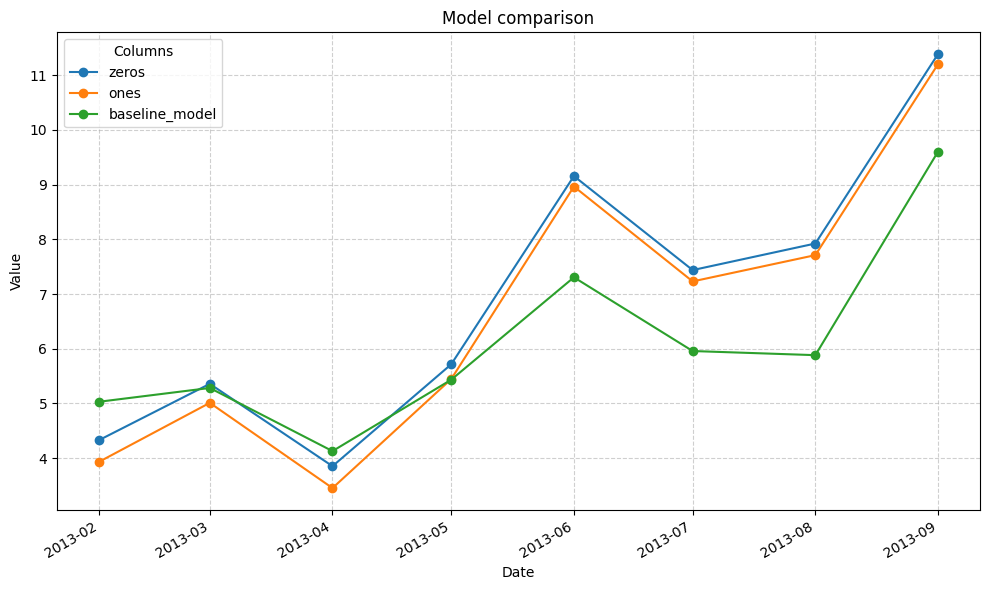

In [ ]:
plot_time_dataframe(compare_consts_df, 'Model comparison')

We can see that overall this model predicts better then constants but after spikes like new year this model has high expectations and looses to constants that keep sales low.

Let's add some complexity to this model by adding seasonal and trend components to it.

In [ ]:
results_seasonal = validation_chema(final_df, SeasonalModel, root_mean_squared_error, start=0, window_size=24)

In [ ]:
results_trend = validation_chema(final_df, TrendModel, root_mean_squared_error, start=0, window_size=24)

In [ ]:
results_seosonal_trend  = validation_chema(final_df, SeasonalTrendModel, root_mean_squared_error, start=0, window_size=24)

In [ ]:
compare_df = pd.DataFrame({'baseline_model': results, 'seasonal_model': results_seasonal, 'trend_model': results_trend, 'seasonal_trend_model': results_seosonal_trend})
compare_df.index = pd.date_range('2015-01-01', periods=len(compare_df), freq='MS').strftime('%Y-%m')
compare_df

,baseline_model,seasonal_model,trend_model,seasonal_trend_model
2015-01,5.031452,7.908141,5.425980,8.339182
2015-02,5.283527,9.789451,5.361224,9.889565
2015-03,4.129755,5.352968,4.173063,5.428183
2015-04,5.434517,6.348361,5.629633,6.651722
2015-05,7.305439,8.796073,7.336922,8.843598
2015-06,5.958368,7.333843,6.027258,7.453255
2015-07,5.882927,5.120245,5.940518,5.219372
2015-08,9.602365,10.289192,9.644362,10.346811


In [ ]:
compare_df.mean()

baseline_model          6.078544
seasonal_model          7.617284
trend_model             6.192370
seasonal_trend_model    7.771461
dtype: float64

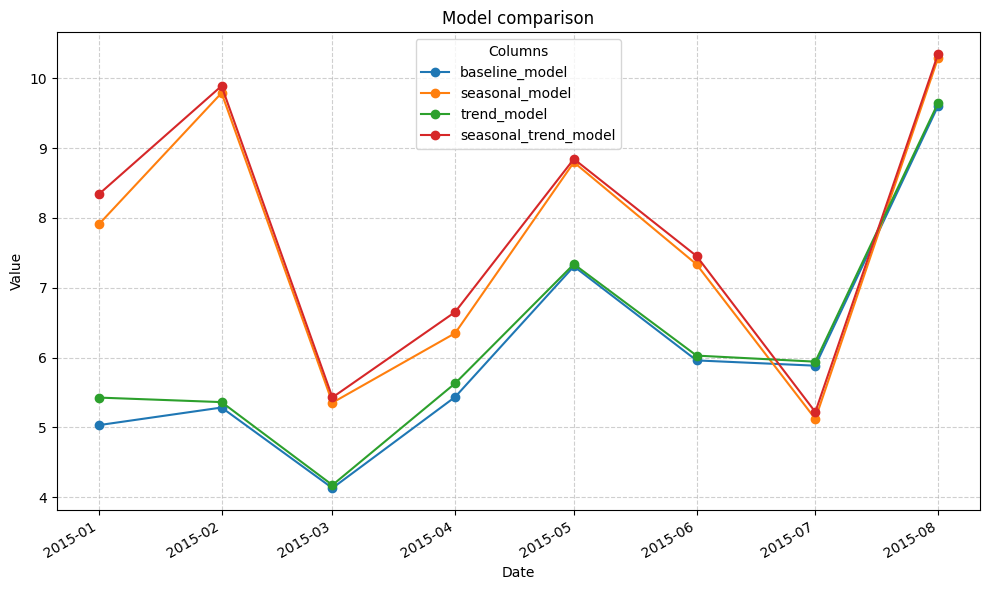

In [ ]:
plot_time_dataframe(compare_df, 'Model comparison')

As we don't have enough data(only 2 years) seosonal and trend components are noisy and don't provide anything useful by simply adding them.

In [ ]:
compare_df = pd.DataFrame({'baseline_model': results, 'seasonal_model': results_seasonal})
compare_df.index = pd.date_range('2015-01-01', periods=len(compare_df), freq='MS').strftime('%Y-%m')
compare_df

,baseline_model,seasonal_model
2015-01,5.031452,7.908141
2015-02,5.283527,9.789451
2015-03,4.129755,5.352968
2015-04,5.434517,6.348361
2015-05,7.305439,8.796073
2015-06,5.958368,7.333843
2015-07,5.882927,5.120245
2015-08,9.602365,10.289192


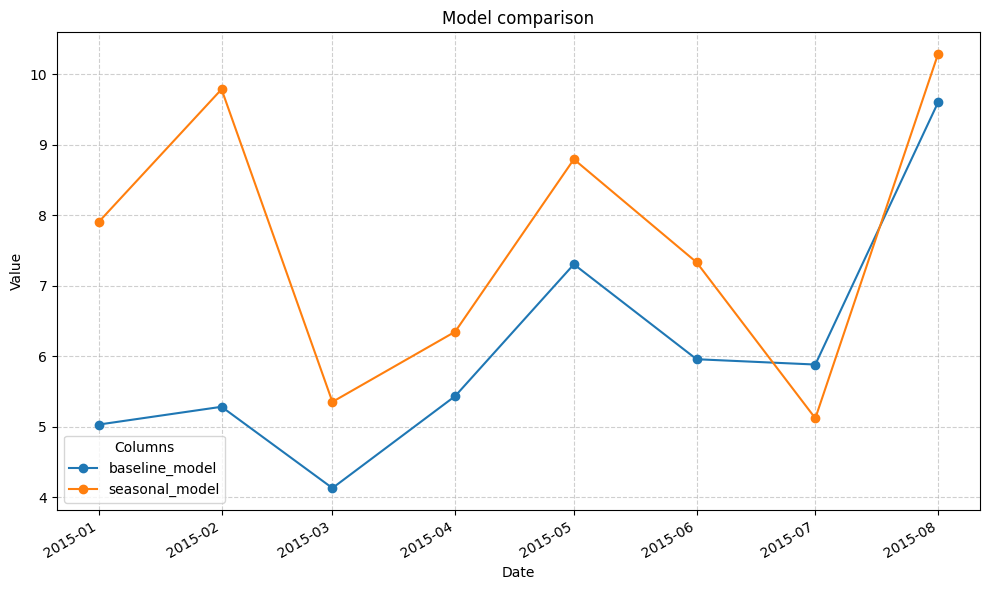

In [ ]:
plot_time_dataframe(compare_df, 'Model comparison')

In [15]:
baseline_results

,date_block_num,corrected_shop_id,corrected_item_id,item_cnt_day,true_ans
0,1,2,31,0.0,4.0
1,1,2,482,1.0,1.0
2,1,2,484,2.0,4.0
3,1,2,496,0.0,1.0
4,1,2,785,1.0,1.0
...,...,...,...,...,...
1545456,33,59,22087,3.0,6.0
1545457,33,59,22088,1.0,2.0
1545458,33,59,22091,3.0,1.0
1545459,33,59,22100,1.0,1.0


In [16]:
def rmse_by_month(df):
    return df.groupby("date_block_num").apply(
        lambda x: root_mean_squared_error(x["true_ans"], x["item_cnt_day"])
    )

In [17]:
compare_24 = pd.DataFrame({
    "baseline": rmse_by_month(baseline_results24),
    "seasonal": rmse_by_month(seasonal_results24),
    "trend": rmse_by_month(trend_results24),
    "seasonal_trend": rmse_by_month(seasonal_trend_results24),
    "stats_seasonal": rmse_by_month(stats_seasonal_results24),
    "stats_trend": rmse_by_month(stats_trend_results24),
    "stats_seasonal_trend": rmse_by_month(stats_seasonal_trend_results24),
})
compare_24.index = pd.date_range('2015-01-01', periods=len(compare_24), freq='MS').strftime('%Y-%m')
compare_24

C:\Users\user\AppData\Local\Temp\ipykernel_17888\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date_block_num").apply(
C:\Users\user\AppData\Local\Temp\ipykernel_17888\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("date_block_num").apply(
C:\Users\user\AppData\Local\Temp\ipykernel_17888\945072317.py:2: FutureWarning: DataFrameGroupBy.apply operated 

,baseline,seasonal,trend,seasonal_trend,stats_seasonal,stats_trend,stats_seasonal_trend
2015-01,5.031452,7.908141,5.425980,8.339182,4.653881,5.062877,4.676113
2015-02,5.283527,9.789451,5.361224,9.889565,5.365799,5.294086,5.383320
2015-03,4.129755,5.352968,4.173063,5.428183,4.445352,4.146485,4.478018
2015-04,5.434517,6.348361,5.629633,6.651722,5.719489,5.471189,5.740346
2015-05,7.305439,8.796073,7.336922,8.843598,7.508192,7.351303,7.552715
2015-06,5.958368,7.333843,6.027258,7.453255,5.422150,6.015925,5.471847
2015-07,5.882927,5.120245,5.940518,5.219372,6.072924,5.920093,6.120088
2015-08,9.602365,10.289192,9.644362,10.346811,9.628951,9.629644,9.656671
2015-09,7.958684,10.716172,8.007201,10.792419,7.869123,7.986037,7.899089
2015-10,7.972118,9.900994,8.029738,10.031128,8.041857,8.002094,8.071439


In [19]:
compare_24.mean()

baseline                6.455915
seasonal                8.155544
trend                   6.557590
seasonal_trend          8.299524
stats_seasonal          6.472772
stats_trend             6.487973
stats_seasonal_trend    6.504965
dtype: float64

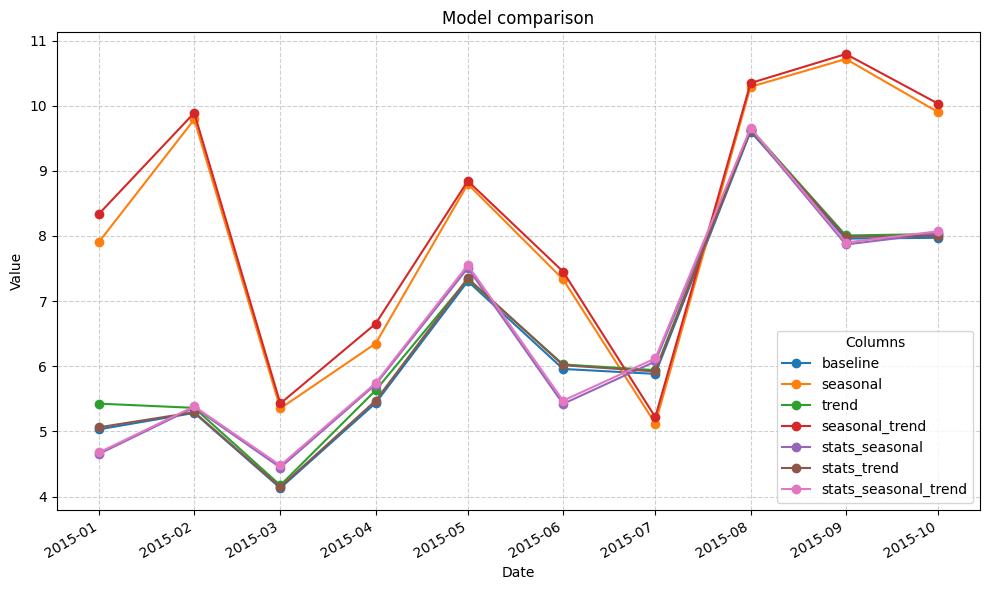

In [18]:
plot_time_dataframe(compare_24, 'Model comparison')

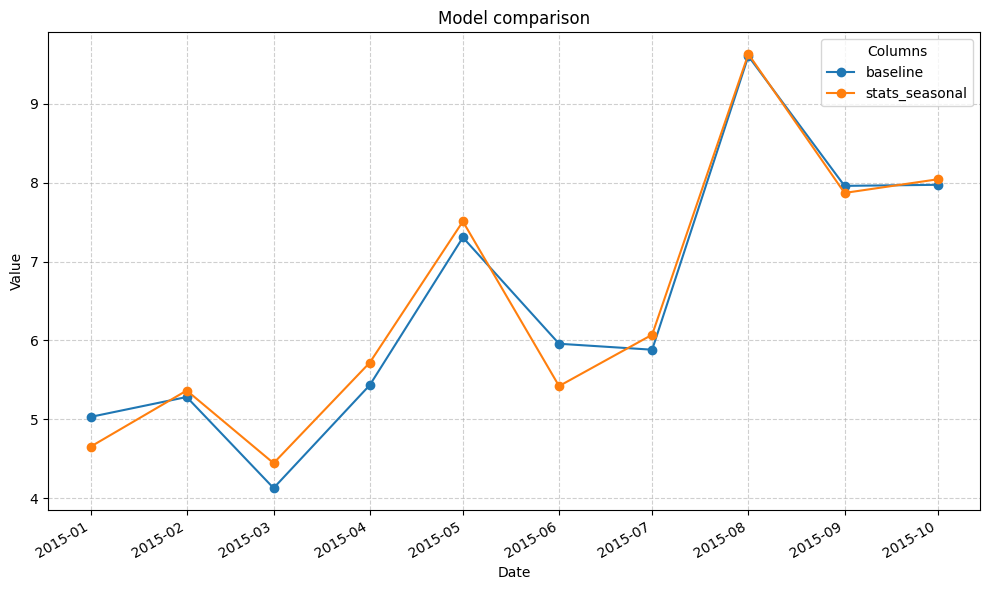

In [23]:
plot_time_dataframe(compare_24[['baseline', 'stats_seasonal']], 'Model comparison')